# Flower Classification using CNN

In [1]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path(r"C:\Users\hp\Desktop\Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Already extracted. Skipping.
Candidate dataset roots: ['data\\flower_data\\Data', 'data\\flower_data\\Data\\train', 'data\\flower_data\\Data\\val']


### Part 1: Data Exploration and Visualization


In [2]:
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"), None)
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"), None)
    if train_dir is None or val_dir is None:
        raise FileNotFoundError(f"Expected 'train' and 'val' directories under {base}; found train={train_dir}, val={val_dir}")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)


Layout: provided_split Base: data\flower_data\Data
Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [3]:
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(root).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

# Use the already-detected `base` Path from earlier cells
counts = count_images_per_class(base)
counts


{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

In [4]:
def visualize_images(dataset, class_names, per_class=9):
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(15, 15))
    displayed = {cls: 0 for cls in class_names}
    total_displayed = 0
    
    for images, labels in dataset.unbatch():
        cls = class_names[labels.numpy()]
        if displayed[cls] < per_class:
            ax = plt.subplot(len(class_names), per_class, total_displayed + 1)
            plt.imshow(images.numpy().astype("uint8"))
            plt.title(cls)
            plt.axis("off")
            displayed[cls] += 1
            total_displayed += 1
        if total_displayed >= per_class * len(class_names):
            break
    plt.show()

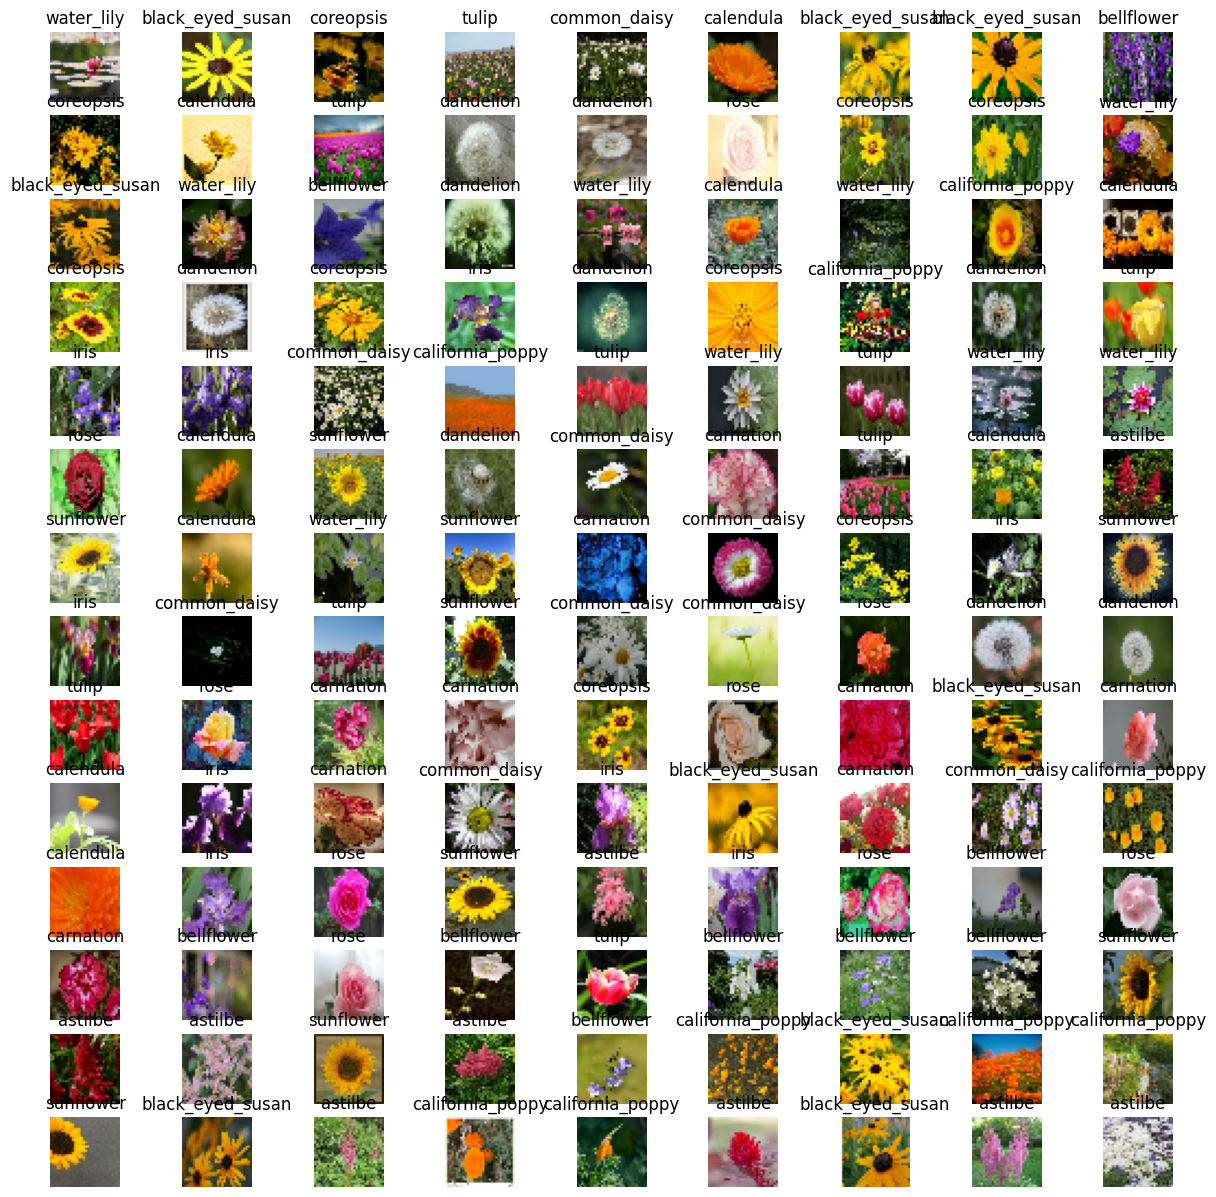

In [6]:
visualize_images(train_ds, class_names, per_class=9)

### Part 2. Model architecture design

In [9]:
from tensorflow.keras import models, layers
def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),
        
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.Dropout(0.4),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.Dropout(0.4),
        layers.MaxPooling2D(),
        
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.Dropout(0.4),
        layers.MaxPooling2D(),
        
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 32, 32, 3)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 dropout_4 (Dropout)         (None, 32, 32, 32)        0         
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 dropout_5 (Dropout)         (None, 16, 16, 64)        0         
                                                      

My baseline CNN architecture uses a strategic progression of convolutional and regularization layers. The sequence of 3×3 convolutions (32→64→128 filters) with increasing depth progressively expands the receptive field while maintaining computational efficiency, allowing the network to capture hierarchical features from local edges to complex patterns. I placed batch normalization after each convolutional layer to stabilize training by normalizing activations, which accelerates convergence and reduces sensitivity to weight initialization. The consistent use of 40% dropout after every layer serves as strong regularization to prevent overfitting by randomly deactivating neurons during training. The 2×2 max pooling between convolutional blocks reduces spatial dimensions while preserving important features, controlling model complexity. This balanced design with progressive filtering, normalization, and regularization creates a robust foundation suitable for general image classification tasks before specialization.

### Part 3. Hyperparameter tuning


In [10]:
import time
import matplotlib.pyplot as plt

def fit_model(model, train_ds, val_ds, epochs=5, batch_size=BATCH_SIZE, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [11]:
opts = [
   ("adam", 1e-3, 32),
   ("adam", 5e-4, 32),
   ("rmsprop", 1e-3, 32),
   ("sgd", 1e-2, 64),
]
results = []
for opt_name, lr, batch in opts:
     # rebuild model each time
     model = build_baseline(num_classes)  # or your variant
     if opt_name == "adam":
         optimizer = tf.keras.optimizers.Adam(lr)
     elif opt_name == "rmsprop":
         optimizer = tf.keras.optimizers.RMSprop(lr)
     else:
         optimizer = tf.keras.optimizers.SGD(lr, momentum=0.9, nesterov=True)
     model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
     cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
     hist, dur = fit_model(model, train_ds, val_ds, epochs=8, callbacks=cb)
     best_val = max(hist.history["val_accuracy"])
     results.append({"opt": opt_name, "lr": lr, "batch": batch, "best_val_acc": float(best_val), "time_s": round(dur,1)})
results

Epoch 1/8
427/427 - 84s - loss: 1.8927 - accuracy: 0.3379 - val_loss: 1.9366 - val_accuracy: 0.4592 - 84s/epoch - 196ms/step
Epoch 2/8
427/427 - 57s - loss: 1.4492 - accuracy: 0.4958 - val_loss: 1.6738 - val_accuracy: 0.5102 - 57s/epoch - 133ms/step
Epoch 3/8
427/427 - 47s - loss: 1.2755 - accuracy: 0.5591 - val_loss: 1.5223 - val_accuracy: 0.5510 - 47s/epoch - 110ms/step
Epoch 4/8
427/427 - 39s - loss: 1.1564 - accuracy: 0.6019 - val_loss: 1.4000 - val_accuracy: 0.6122 - 39s/epoch - 90ms/step
Epoch 5/8
427/427 - 24s - loss: 1.0815 - accuracy: 0.6267 - val_loss: 1.2958 - val_accuracy: 0.6429 - 24s/epoch - 56ms/step
Epoch 6/8
427/427 - 25s - loss: 1.0003 - accuracy: 0.6533 - val_loss: 1.2448 - val_accuracy: 0.6633 - 25s/epoch - 59ms/step
Epoch 7/8
427/427 - 23s - loss: 0.9401 - accuracy: 0.6770 - val_loss: 1.1623 - val_accuracy: 0.6735 - 23s/epoch - 55ms/step
Epoch 8/8
427/427 - 25s - loss: 0.8856 - accuracy: 0.6953 - val_loss: 1.0947 - val_accuracy: 0.6735 - 25s/epoch - 58ms/step
Epoch

[{'opt': 'adam',
  'lr': 0.001,
  'batch': 32,
  'best_val_acc': 0.6734693646430969,
  'time_s': 324.9},
 {'opt': 'adam',
  'lr': 0.0005,
  'batch': 32,
  'best_val_acc': 0.6836734414100647,
  'time_s': 224.8},
 {'opt': 'rmsprop',
  'lr': 0.001,
  'batch': 32,
  'best_val_acc': 0.7551020383834839,
  'time_s': 238.5},
 {'opt': 'sgd',
  'lr': 0.01,
  'batch': 64,
  'best_val_acc': 0.6224489808082581,
  'time_s': 236.9}]

Found 10919 images belonging to 14 classes.
Found 2723 images belonging to 14 classes.
Epoch 1/8
342/342 - 49s - loss: 2.0096 - accuracy: 0.2837 - val_loss: 1.9832 - val_accuracy: 0.4275 - 49s/epoch - 143ms/step
Epoch 2/8
342/342 - 39s - loss: 1.6225 - accuracy: 0.4283 - val_loss: 1.8451 - val_accuracy: 0.4870 - 39s/epoch - 113ms/step
Epoch 3/8
342/342 - 42s - loss: 1.4647 - accuracy: 0.4878 - val_loss: 1.6468 - val_accuracy: 0.5035 - 42s/epoch - 122ms/step
Epoch 4/8
342/342 - 38s - loss: 1.3697 - accuracy: 0.5218 - val_loss: 1.6010 - val_accuracy: 0.5189 - 38s/epoch - 112ms/step
Epoch 5/8
342/342 - 41s - loss: 1.2927 - accuracy: 0.5514 - val_loss: 1.5093 - val_accuracy: 0.5689 - 41s/epoch - 121ms/step
Epoch 6/8
342/342 - 49s - loss: 1.2284 - accuracy: 0.5721 - val_loss: 1.4329 - val_accuracy: 0.5766 - 49s/epoch - 142ms/step
Epoch 7/8
342/342 - 44s - loss: 1.1686 - accuracy: 0.5975 - val_loss: 1.3081 - val_accuracy: 0.6100 - 44s/epoch - 129ms/step
Epoch 8/8
342/342 - 45s - loss: 1.1477

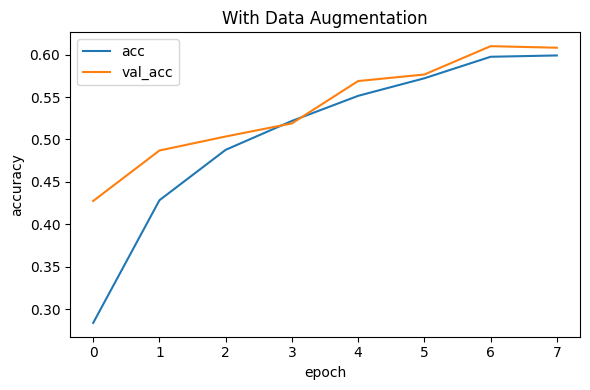

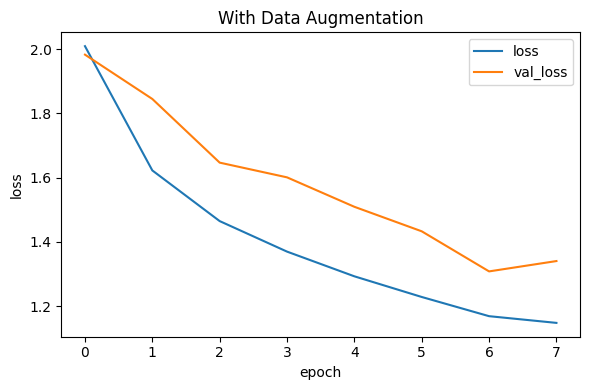

In [13]:
# To-Do: build an ImageDataGenerator pipeline
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# choose directory for flow_from_directory: prefer explicit train_dir if available
data_root = None
if 'train_dir' in globals() and train_dir is not None:
    data_root = train_dir
elif 'base' in globals():
    data_root = base
else:
    raise RuntimeError('No data directory found for ImageDataGenerator')
data_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
flow_train = data_gen.flow_from_directory(
    data_root,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=SEED
)
flow_val = data_gen.flow_from_directory(
    data_root,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=SEED
)
model_aug = build_baseline(num_classes)
hist_aug, dur_aug = fit_model(model_aug, flow_train, flow_val, epochs=8)
plot_curves(hist_aug, title="With Data Augmentation")


### Part 5. Performance evaluation and analysis

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

                  precision    recall  f1-score   support

         astilbe       0.45      0.71      0.56         7
      bellflower       1.00      0.29      0.44         7
black_eyed_susan       0.58      1.00      0.74         7
       calendula       0.60      0.43      0.50         7
california_poppy       0.80      0.57      0.67         7
       carnation       0.75      0.43      0.55         7
    common_daisy       0.55      0.86      0.67         7
       coreopsis       0.67      0.57      0.62         7
       dandelion       0.75      0.86      0.80         7
            iris       0.86      0.86      0.86         7
            rose       1.00      0.29      0.44         7
       sunflower       1.00      0.86      0.92         7
           tulip       0.86      0.86      0.86         7
      water_lily       0.42      0.71      0.53         7

        accuracy                           0.66        98
       macro avg       0.73      0.66      0.65        98
    weighted

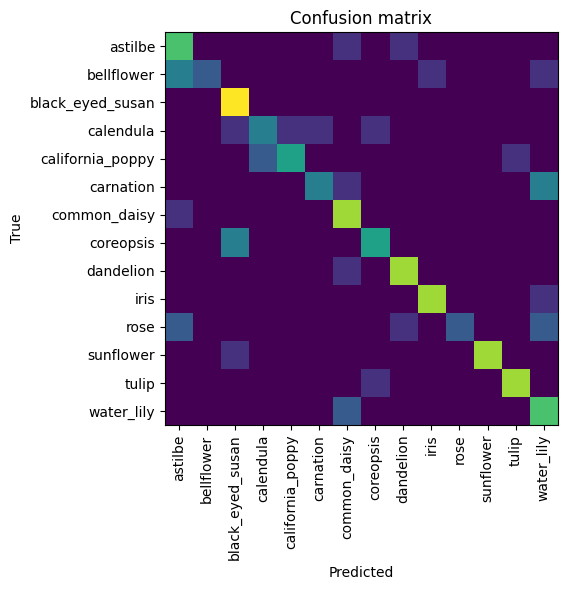

[[5 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [3 2 0 0 0 0 0 0 0 1 0 0 0 1]
 [0 0 7 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 3 1 1 0 1 0 0 0 0 0 0]
 [0 0 0 2 4 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 3 1 0 0 0 0 0 0 3]
 [1 0 0 0 0 0 6 0 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 4 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 6 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 6 0 0 0 1]
 [2 0 0 0 0 0 0 0 1 0 2 0 0 2]
 [0 0 1 0 0 0 0 0 0 0 0 6 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 6 0]
 [0 0 0 0 0 0 2 0 0 0 0 0 0 5]]


In [17]:
best_model = model_aug  # or whichever you prefer
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)
print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
plot_confusion(cm, class_names)
print(cm)

1/1 [==============================] - 0s 19ms/step


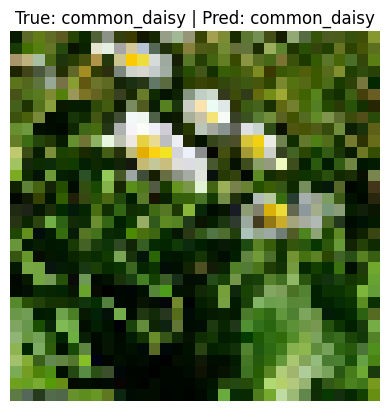

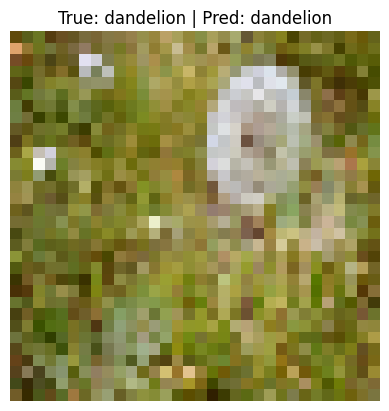

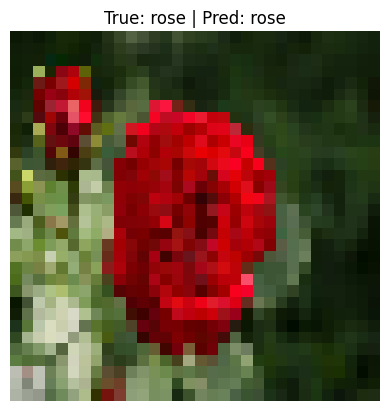

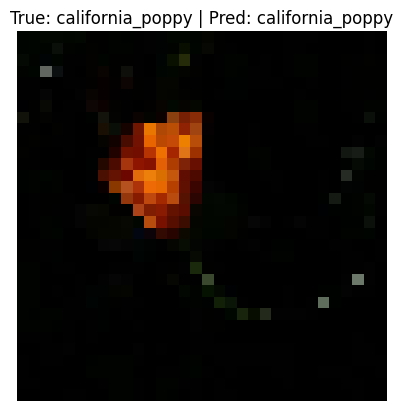

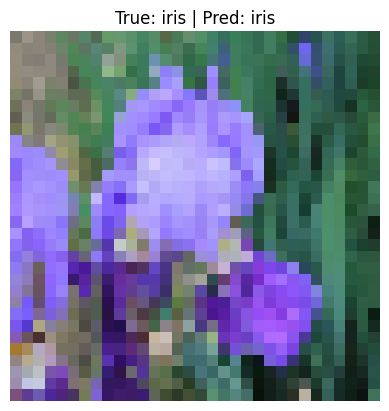

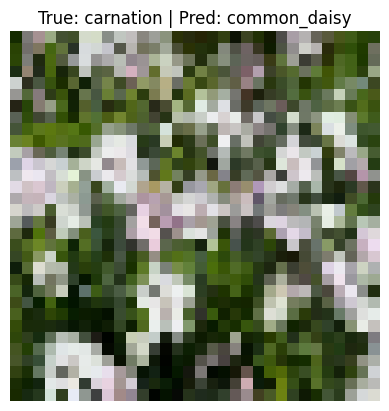

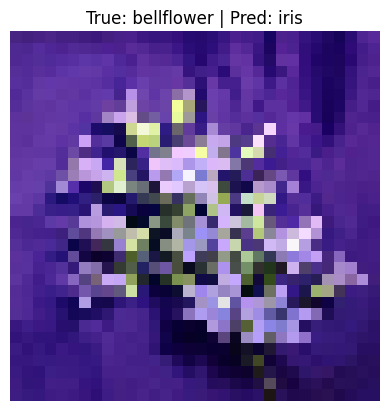

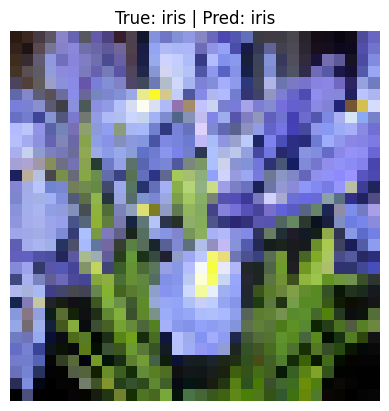

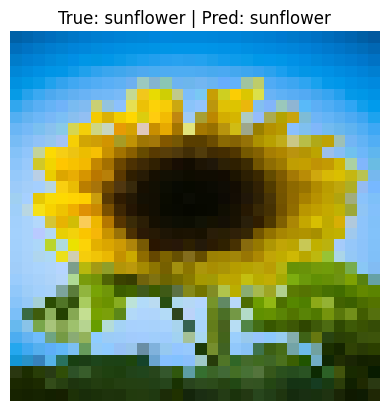

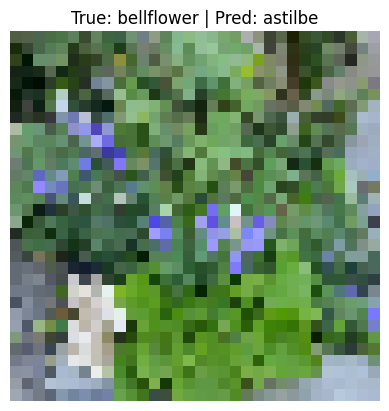

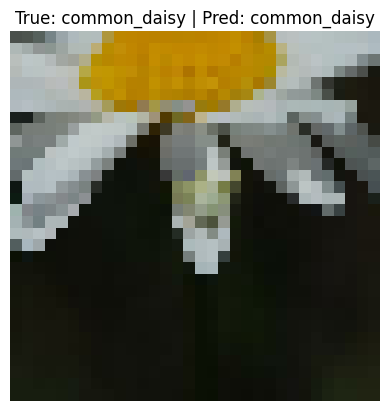

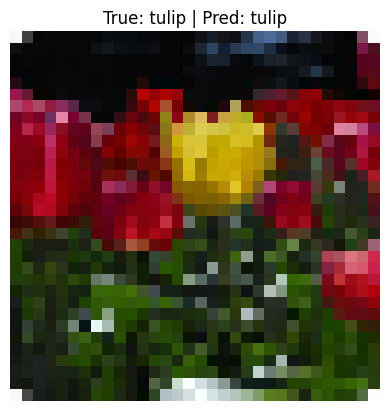

In [18]:
import random
take = 12
imgs, labels = next(iter(val_ds.unbatch().batch(take)))
preds = best_model.predict(imgs)
preds_labels = np.argmax(preds, axis=1)
for i in range(take):
    plt.figure()
    plt.imshow(imgs[i].numpy().astype("uint8"))
    plt.title(f"True: {class_names[labels[i]]} | Pred: {class_names[preds_labels[i]]}")
    plt.axis("off")
    plt.show()